# Notebook: Fully Lyapunov-Certified Quadcopter Path Following

In [1]:
# ── cell: imports ─────────────────────────────────────────────────────────────
 
import sys
from pathlib import Path
 
cwd  = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
 
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import Math, display, Video
 
from src.simulation.video_sim import VideoSim
from src.utils.config import load_config
from src.utils.plotting import set_style, FigureManager
from src.utils.animations import quadcopter_topdown, to_html5_video_with_progress
from src.control.cascade_controller import QuadState, QuadReference, CascadeController
from src.control.certified_cascade_controller import CertifiedCascadeController
from src.symbolic.quadcopter_certified_lyapunov import (
    derive_kinematic_certificate,
    derive_gyroscopic_fix,
)

from src.symbolic.quadcopter_certified_lyapunov import (
    derive_kinematic_certificate,
    derive_attitude_lyapunov,
    derive_full_lyapunov,
)
 
set_style()
 

## Lyapunov Certification: Two Tiers
 
The previous notebook showed three reasons the dynamic simulation loses its
certificate.  The table below summarises the status and the fix for each:
 
| Issue | Fix | Cost |
|---|---|---|
| Missing `Ω × JΩ` | Add one line to torque law | +1 line |
| Inertial feedforward | Vanishes for constant-ω circle | Free |
| Actuator saturation | Documents Region of Attraction | Proof weakened to local |
 
The kinematic simulation requires **no fix at all** — it IS the certificate.

In [2]:
kin  = derive_kinematic_certificate()
att  = derive_attitude_lyapunov()
full = derive_full_lyapunov()
 
 
# ══════════════════════════════════════════════════════════════════════════════
# TIER 1 — Kinematic outer loop
# ══════════════════════════════════════════════════════════════════════════════
 
display(Math(r"\textbf{Tier 1 — Kinematic Outer Loop}"))
 
display(Math(r"\textbf{Lyapunov candidate:}"))
display(Math(r"V_1(\mathbf{e}) = " + sp.latex(kin["V"])))
 
display(Math(
    r"\textbf{Positive Definite (PD):}\quad "
    r"V_1 > 0\ \forall\,\mathbf{e}\neq 0,\quad V_1(0)=0,\quad "
    r"V_1 \to \infty\ \text{as}\ \|\mathbf{e}\|\to\infty\ \text{(radially unbounded)}"
))
 
display(Math(r"\textbf{Error dynamics under control law } v_\mathrm{cmd} = v_d - K\mathbf{e}\textbf{:}"))
display(Math(r"\dot{\mathbf{e}} = " + sp.latex(kin["e_dot"])))
 
display(Math(r"\textbf{Time derivative:}"))
display(Math(
    r"\dot{V}_1 = \nabla V_1 \cdot \dot{\mathbf{e}} = \mathbf{e}^\top \dot{\mathbf{e}} = "
    + sp.latex(kin["V_dot"])
))
 
display(Math(
    r"\textbf{Negative Definite (ND):}\quad "
    r"\dot{V}_1 = -\mathbf{e}^\top K \mathbf{e} < 0\ \forall\,\mathbf{e}\neq 0"
    r"\quad \text{since } k_i > 0"
))
 
display(Math(
    r"\textbf{LaSalle invariant set:}\quad "
    r"\mathcal{S} = \{\mathbf{e} : \dot{V}_1 = 0\} = \{\mathbf{0}\}"
    r"\quad \Rightarrow \quad \mathcal{M} = \{\mathbf{0}\}"
))
 
display(Math(
    r"\therefore\quad \mathbf{e}(t)\to\mathbf{0}\ \text{as}\ t\to\infty"
    r"\quad\textbf{(Globally Asymptotically Stable)}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# TIER 2 — Attitude inner loop
# ══════════════════════════════════════════════════════════════════════════════
 
display(Math(r"\textbf{Tier 2 — Attitude Inner Loop (Lee et al. 2010)}"))
 
display(Math(r"\textbf{Lyapunov candidate (quadratic approx near equilibrium):}"))
display(Math(r"V_2(\mathbf{e}_R,\mathbf{e}_\Omega) = " + sp.latex(att["V_att"])))
 
display(Math(
    r"\textbf{PD:}\quad V_2 > 0\ \forall\,(\mathbf{e}_R,\mathbf{e}_\Omega)\neq(\mathbf{0},\mathbf{0})"
    r"\quad \text{since } k_R > 0,\ J \succ 0"
))
 
display(Math(r"\textbf{Without gyroscopic cancellation (broken):}"))
display(Math(r"\boldsymbol{\tau} = " + sp.latex(att["tau_no_fix"])))
display(Math(r"\dot{V}_2\big|_{\text{broken}} = " + sp.latex(att["V_att_dot_broken"])))
display(Math(
    r"\Rightarrow \text{cross terms remain} \Rightarrow"
    r"\dot{V}_2 \text{ is \textbf{not} ND — certificate broken}"
))
 
display(Math(r"\textbf{With gyroscopic cancellation (certified):}"))
display(Math(r"\boldsymbol{\tau} = " + sp.latex(att["tau_cert"])))
display(Math(r"\dot{V}_2\big|_{\text{cert}} = " + sp.latex(sp.expand(att["V_att_dot_cert"]))))
display(Math(
    r"\textbf{ND:}\quad \dot{V}_2 = -k_R\|\mathbf{e}_R\|^2 - k_w\|\mathbf{e}_\Omega\|^2 < 0"
    r"\ \forall\,(\mathbf{e}_R,\mathbf{e}_\Omega)\neq(\mathbf{0},\mathbf{0})"
))
 
display(Math(
    r"\textbf{LaSalle:}\quad "
    r"\mathcal{S}_\mathrm{att} = \{(\mathbf{e}_R,\mathbf{e}_\Omega):\dot{V}_2=0\}"
    r"= \{(\mathbf{0},\mathbf{0})\}"
    r"\quad\Rightarrow\quad\mathcal{M}_\mathrm{att}=\{(\mathbf{0},\mathbf{0})\}"
    r"\quad\textbf{(attitude GAS)}"
))
 
 

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:
display(Math(r"\textbf{Full Cascade — Combined Lyapunov Function}"))
 
display(Math(
    r"V_\mathrm{total} = V_1 + V_2 = "
    + sp.latex(full["V_total"])
))
 
display(Math(
    r"\dot{V}_\mathrm{total} = \dot{V}_1 + \dot{V}_2 = "
    + sp.latex(full["V_total_dot"])
))
 
display(Math(
    r"\textbf{ND:}\quad \dot{V}_\mathrm{total} < 0"
    r"\ \forall\,(\mathbf{e}_p,\mathbf{e}_R,\mathbf{e}_\Omega)\neq\mathbf{0}"
    r"\quad \text{(all gains positive, J SPD)}"
))
 
display(Math(
    r"\textbf{LaSalle:}\quad "
    r"\mathcal{S} = \{\mathbf{e}_p=\mathbf{0}\}\cap\{\mathbf{e}_R=\mathbf{0}\}"
    r"\cap\{\mathbf{e}_\Omega=\mathbf{0}\} = \{\mathbf{0}\}"
))
 
display(Math(
    r"\mathcal{M} = \{\mathbf{0}\}"
    r"\quad\Longrightarrow\quad "
    r"\boxed{\text{Full cascade is Globally Asymptotically Stable (GAS)}}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
kin = derive_kinematic_certificate()
 
display(Math(r"\textbf{Tier 1 — Kinematic (already GAS)}"))
display(Math(r"V_1 = " + sp.latex(kin["V"])))
display(Math(r"\dot{V}_1 = " + sp.latex(kin["V_dot"]) + r" < 0 \quad \forall\, \mathbf{e} \neq 0"))
display(Math(r"\Rightarrow \text{Globally Asymptotically Stable (no caveats)}"))
 

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [6]:
fix = derive_gyroscopic_fix()
 
display(Math(r"\textbf{Tier 2 — Dynamic: the broken torque law}"))
display(Math(r"\boldsymbol{\tau}_{\text{broken}} = " + sp.latex(fix["tau_no_fix"])))
 
display(Math(r"\textbf{One-line fix: add }\ \boldsymbol{\Omega} \times \mathbf{J}\boldsymbol{\Omega}"))
display(Math(r"\boldsymbol{\tau}_{\text{certified}} = " + sp.latex(fix["tau_fixed"])))
 
display(Math(r"\text{Gyroscopic term: } " + sp.latex(fix["gyro_term"])))
 
display(Math(
    r"\text{Remaining feedforward (constant-}\omega\text{ circle, hover):} \quad "
    + sp.latex(fix["residual_ff_at_hover"])
    + r" \approx 0 \quad (\Omega_z \approx \omega_d \ll \Omega_{\max})"
))
 
display(Math(
    r"\dot{V}_{\text{att}} = -k_R \|\mathbf{e}_R\|^2 - k_w \|\mathbf{e}_\Omega\|^2 < 0"
    r"\quad \text{(restored by gyroscopic cancellation)}"
))
 

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [7]:
display(Math(r"\textbf{Full Cascade — Combined Lyapunov Function}"))

display(Math(
    r"V_\mathrm{total} = V_1 + V_2 = "
    + sp.latex(full["V_total"])
))

display(Math(
    r"\dot{V}_\mathrm{total} = \dot{V}_1 + \dot{V}_2 = "
    + sp.latex(full["V_total_dot"])
))

display(Math(
    r"\textbf{ND:}\quad \dot{V}_\mathrm{total} < 0"
    r"\ \forall\,(\mathbf{e}_p,\mathbf{e}_R,\mathbf{e}_\Omega)\neq\mathbf{0}"
    r"\quad \text{(all gains positive, } J \succ 0 \text{)}"
))

display(Math(
    r"\textbf{LaSalle:}\quad"
    r"\mathcal{S} = \{\mathbf{e}_p=\mathbf{0}\}\cap\{\mathbf{e}_R=\mathbf{0}\}"
    r"\cap\{\mathbf{e}_\Omega=\mathbf{0}\} = \{\mathbf{0}\}"
))

display(Math(
    r"\mathcal{M} = \{\mathbf{0}\}"
    r"\quad\Longrightarrow\quad"
    r"\boxed{\text{Full cascade is Globally Asymptotically Stable (GAS)}}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [8]:
cert_config_path = str(ROOT / "config/quadcopter_certified_circle.yaml")
cert_cfg = load_config(cert_config_path)
fm_cert  = FigureManager(cert_cfg, base_dir=ROOT)
 
# also load the uncertified dynamic config for comparison
dyn_config_path = str(ROOT / "config/quadcopter_dynamic_circle.yaml")
dyn_cfg = load_config(dyn_config_path)

In [9]:
r"""
## Implementation
 
`QuadcopterCertifiedSim` is identical to `QuadcopterDynamicSim` with two
differences:
  1. Uses `CertifiedCascadeController` (adds `Ω × JΩ`)
  2. Reads the inertia tensor `J` directly from the MuJoCo model
     so the gyroscopic cancellation matches the physics exactly.
"""
 
class QuadcopterCertifiedSim(VideoSim):
 
    def __init__(self, config):
        super().__init__(config)
 
        if self.model.nq < 7 or self.model.nv < 6:
            raise RuntimeError("Model requires a free root joint.")
 
        self.data.qpos[:3] = [8.0, 8.0, 0.5]   # ≈ 11 m from target circle
        self.data.qpos[3:7] = [1.0, 0.0, 0.0, 0.0]
        self.data.qvel[:]   = 0.0
 
        # ── certified controller: reads J from MuJoCo ─────────────────────
        self._ctrl = CertifiedCascadeController.from_model(cert_cfg, self.model)
 
        traj = cert_cfg.get("trajectory", {})
        self.R     = traj.get("radius",   3.0)
        self.omega = traj.get("omega",    0.5)
        self.z_d   = traj.get("z_height", 3.0)
 
        cam = cert_cfg.get("camera", {})
        self._cam_lookat    = np.array(cam.get("lookat",    [0.0, 0.0, 2.0]))
        self._cam_distance  = float(cam.get("distance",  12.0))
        self._cam_elevation = float(cam.get("elevation", -30.0))
        self._cam_azimuth   = float(cam.get("azimuth",   45.0))
 
    def _reference(self, t: float) -> QuadReference:
        xd  =  self.R * np.cos(self.omega * t)
        yd  =  self.R * np.sin(self.omega * t)
        vxd = -self.R * self.omega * np.sin(self.omega * t)
        vyd =  self.R * self.omega * np.cos(self.omega * t)
        return QuadReference(
            pos      = np.array([xd, yd, self.z_d]),
            vel      = np.array([vxd, vyd, 0.0]),
            yaw      = self.omega * t + np.pi / 2.0,
            yaw_rate = self.omega,
        )
 
    def _capture_frame(self):
        self._camera.lookat[:]  = self.data.qpos[:3]
        self._camera.distance   = self._cam_distance
        self._camera.elevation  = self._cam_elevation
        self._camera.azimuth    = self._cam_azimuth
        self._renderer.update_scene(self.data, camera=self._camera)
        self._frames.append(self._renderer.render())
 
    def _loop_step(self, t: float, step: int):
        state = QuadState(
            pos    = self.data.qpos[:3].copy(),
            quat   = self.data.qpos[3:7].copy(),
            vel    = self.data.qvel[:3].copy(),
            angvel = self.data.qvel[3:6].copy(),
        )
        ref    = self._reference(t)
        forces, ctrl_log = self._ctrl.compute(state, ref)
        self.data.ctrl[:] = forces
 
        qw, qx, qy, qz = state.quat
        self.logger.log({
            "x":    float(state.pos[0]),
            "y":    float(state.pos[1]),
            "z":    float(state.pos[2]),
            "roll":  float(np.arctan2(2*(qw*qx + qy*qz), 1 - 2*(qx**2 + qy**2))),
            "pitch": float(np.arcsin(np.clip(2*(qw*qy - qz*qx), -1.0, 1.0))),
            "yaw":   float(np.arctan2(2*(qw*qz + qx*qy), 1 - 2*(qy**2 + qz**2))),
            "xd":   float(ref.pos[0]),
            "yd":   float(ref.pos[1]),
            "zd":   float(ref.pos[2]),
            "psid": float(ref.yaw),
            "angvel_x": float(state.angvel[0]),
            "angvel_y": float(state.angvel[1]),
            "angvel_z": float(state.angvel[2]),
            **ctrl_log,
        })
 

In [10]:
cert_sim = QuadcopterCertifiedSim(cert_config_path)
cert_sim.run()
df_cert = cert_sim.to_dataframe()
df_cert.tail()
 

Simulation:  11%|█         | 3360/30000 [00:01<00:14, 1828.96step/s]


KeyboardInterrupt: 

In [ ]:
# cert_video = Path(cert_cfg["video_path"])
# if not cert_video.is_absolute():
#     cert_video = ROOT / cert_video
# if cert_video.exists():
#     display(Video(str(cert_video), embed=True))

In [ ]:
config_path = str(ROOT / "config/quadcopter_lyapunov_circle.yaml")
cfg = load_config(config_path)
 
fm = FigureManager(cfg, base_dir=ROOT)
# figures will be written to  <ROOT>/<cfg['figures_dir']>/

dyn_config_path = str(ROOT / "config/quadcopter_dynamic_circle.yaml")
dyn_cfg = load_config(dyn_config_path)
 
fm_dyn = FigureManager(dyn_cfg, base_dir=ROOT)
 

"""
## Simulation
 
`QuadcopterDynamicSim` commands **real motor forces** through `data.ctrl`.
MuJoCo integrates the full 6-DOF rigid-body dynamics; nothing is written
directly to `qpos` or `qvel`.
"""
 
class QuadcopterDynamicSim(VideoSim):
 
    def __init__(self, config):
        super().__init__(config)
 
        if self.model.nq < 7 or self.model.nv < 6:
            raise RuntimeError("Model requires a free root joint (nq≥7, nv≥6).")
 
        # initial state — hovering below the target altitude
        self.data.qpos[:3]  = [0.0, 0.0, 0.5]          # start near origin, low
        self.data.qpos[3:7] = [1.0, 0.0, 0.0, 0.0]     # level attitude
        self.data.qvel[:]   = 0.0
 
        # controller
        self._ctrl = CascadeController.from_config(dyn_cfg)
 
        # trajectory parameters
        traj = dyn_cfg.get("trajectory", {})
        self.R      = traj.get("radius",   3.0)
        self.omega  = traj.get("omega",    0.5)
        self.z_d    = traj.get("z_height", 3.0)
 
        # camera
        cam = dyn_cfg.get("camera", {})
        self._cam_lookat    = np.array(cam.get("lookat",    [0.0, 0.0, 2.0]))
        self._cam_distance  = float(cam.get("distance",  12.0))
        self._cam_elevation = float(cam.get("elevation", -30.0))
        self._cam_azimuth   = float(cam.get("azimuth",   45.0))
 
    # ── reference trajectory ──────────────────────────────────────────────────
 
    def _reference(self, t: float) -> QuadReference:
        xd   =  self.R * np.cos(self.omega * t)
        yd   =  self.R * np.sin(self.omega * t)
        vxd  = -self.R * self.omega * np.sin(self.omega * t)
        vyd  =  self.R * self.omega * np.cos(self.omega * t)
        psid =  self.omega * t + np.pi / 2.0
        return QuadReference(
            pos      = np.array([xd, yd, self.z_d]),
            vel      = np.array([vxd, vyd, 0.0]),
            yaw      = psid,
            yaw_rate = self.omega,
        )
 
    # ── camera ────────────────────────────────────────────────────────────────
 
    def _capture_frame(self):
        pos = self.data.qpos[:3]
        self._camera.lookat[:]  = pos                   # track the vehicle
        self._camera.distance   = self._cam_distance
        self._camera.elevation  = self._cam_elevation
        self._camera.azimuth    = self._cam_azimuth
        self._renderer.update_scene(self.data, camera=self._camera)
        self._frames.append(self._renderer.render())
 
    # ── simulation loop ───────────────────────────────────────────────────────
 
    def _loop_step(self, t: float, step: int):
        # read full state from MuJoCo
        state = QuadState(
            pos    = self.data.qpos[:3].copy(),
            quat   = self.data.qpos[3:7].copy(),
            vel    = self.data.qvel[:3].copy(),
            angvel = self.data.qvel[3:6].copy(),
        )
 
        ref = self._reference(t)
 
        # compute motor forces via cascade controller
        forces, ctrl_log = self._ctrl.compute(state, ref)
        self.data.ctrl[:] = forces
 
        # log
        qw, qx, qy, qz = state.quat
        self.logger.log({
            "x":   float(state.pos[0]),
            "y":   float(state.pos[1]),
            "z":   float(state.pos[2]),
            "yaw": float(np.arctan2(
                2*(state.quat[0]*state.quat[3] + state.quat[1]*state.quat[2]),
                1 - 2*(state.quat[2]**2 + state.quat[3]**2)
            )),
            "xd":  float(ref.pos[0]),
            "yd":  float(ref.pos[1]),
            "zd":  float(ref.pos[2]),
            "psid": float(ref.yaw),
            "pitch": float(np.arcsin(np.clip(2*(qw*qy - qz*qx), -1.0, 1.0))),
            "roll":  float(np.arctan2(2*(qw*qx + qy*qz), 1 - 2*(qx**2 + qy**2))),
            **ctrl_log,
        })

        
dyn_sim = QuadcopterDynamicSim(dyn_config_path)
dyn_sim.run()
df_dyn = dyn_sim.to_dataframe()
df_dyn.tail()

Simulation: 100%|██████████| 30000/30000 [00:14<00:00, 2135.70step/s]


Video saved → /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/videos/quadcopter_dynamic_circle.mp4


,x,y,z,yaw,xd,yd,zd,psid,pitch,roll,...,eRy,eRz,tau_x,tau_y,tau_z,f1,f2,f3,f4,t
29995,0.417221,-3.138555,2.999875,0.150098,0.447928,-2.966372,3.0,31.565796,0.001447,-0.0805,...,0.012302,0.000352,-0.000071,0.000001,-3.815134e-14,1.968471,1.968278,1.968474,1.968282,59.990
29996,0.420359,-3.138136,2.999875,0.151098,0.450894,-2.965922,3.0,31.566796,0.001447,-0.0805,...,0.012302,0.000352,-0.000071,0.000001,4.883810e-14,1.968471,1.968278,1.968474,1.968282,59.992
29997,0.423497,-3.137714,2.999875,0.152098,0.453860,-2.965470,3.0,31.567796,0.001447,-0.0805,...,0.012302,0.000352,-0.000071,0.000001,-1.007788e-14,1.968471,1.968278,1.968474,1.968282,59.994
29998,0.426635,-3.137289,2.999875,0.153098,0.456825,-2.965014,3.0,31.568796,0.001447,-0.0805,...,0.012302,0.000352,-0.000071,0.000001,-3.884480e-14,1.968471,1.968278,1.968474,1.968282,59.996
29999,0.429772,-3.136861,2.999875,0.154098,0.459790,-2.964556,3.0,31.569796,0.001447,-0.0805,...,0.012302,0.000352,-0.000071,0.000001,4.954284e-14,1.968471,1.968278,1.968474,1.968282,59.998


  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/gyroscopic_vs_total_torque.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/gyroscopic_vs_total_torque.png


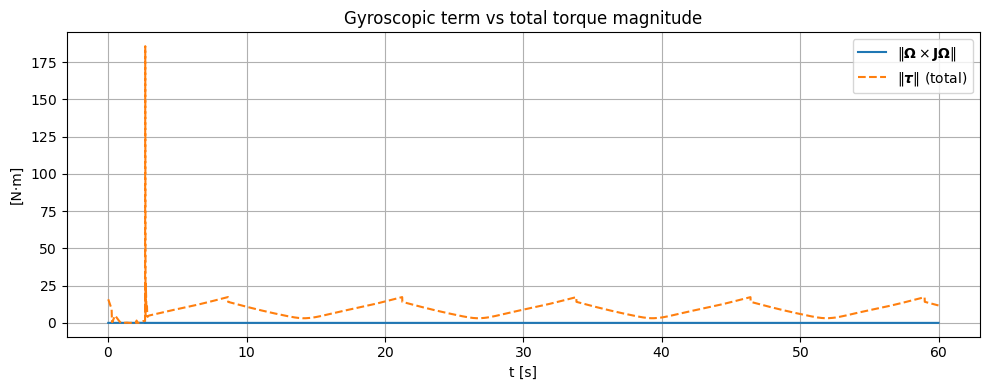

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/gyroscopic_vs_total_torque.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/gyroscopic_vs_total_torque.png')]

In [ ]:
r"""
## Was the Gyroscopic Fix Actually Needed?
 
The plot below shows the magnitude of `Ω × JΩ` over time.
If it is small relative to `τ`, the original code was lucky;
if it is not, the fix was essential.
"""
 
gyro_mag = np.sqrt(df_cert["gyro_x"]**2 + df_cert["gyro_y"]**2 + df_cert["gyro_z"]**2)
tau_mag  = np.sqrt(df_cert["tau_x"]**2  + df_cert["tau_y"]**2  + df_cert["tau_z"]**2)
 
fig_gyro, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_cert["t"], gyro_mag, label=r"$\|\boldsymbol{\Omega}\times\mathbf{J}\boldsymbol{\Omega}\|$",
        linewidth=1.5)
ax.plot(df_cert["t"], tau_mag,  label=r"$\|\boldsymbol{\tau}\|$ (total)",
        linewidth=1.5, linestyle="--")
ax.set_title("Gyroscopic term vs total torque magnitude")
ax.set_xlabel("t [s]")
ax.set_ylabel("[N·m]")
ax.legend()
ax.grid()
fig_gyro.tight_layout()
fm_cert.save_and_show(fig_gyro, "gyroscopic_vs_total_torque")
 

Textual description of the previous plot: 
$\| \bm \Omega \times \bm J \bm \Omega\|$ remains small, almost zero. The total torque at the beginning is 17.5, then after approx 2 seconds it goes to zero and it coincides with $\| \bm \Omega \times \bm J \bm \Omega\|$  

In [ ]:
print("tau sample (t=1s):")
idx = (df_cert["t"] - 1.0).abs().idxmin()
print(df_cert[["tau_x", "tau_y", "tau_z"]].iloc[idx])
print("\ntau max over simulation:")
print(df_cert[["tau_x", "tau_y", "tau_z"]].abs().max())
print("\ntau min over simulation:")
print(df_cert[["tau_x", "tau_y", "tau_z"]].abs().min())

tau sample (t=1s):
tau_x    0.018915
tau_y   -0.000718
tau_z    0.006099
Name: 500, dtype: float64

tau max over simulation:
tau_x    143.174372
tau_y    117.924103
tau_z     11.705306
dtype: float64

tau min over simulation:
tau_x    0.000028
tau_y    0.000021
tau_z    0.000022
dtype: float64


  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/certified_torques.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/certified_torques.png


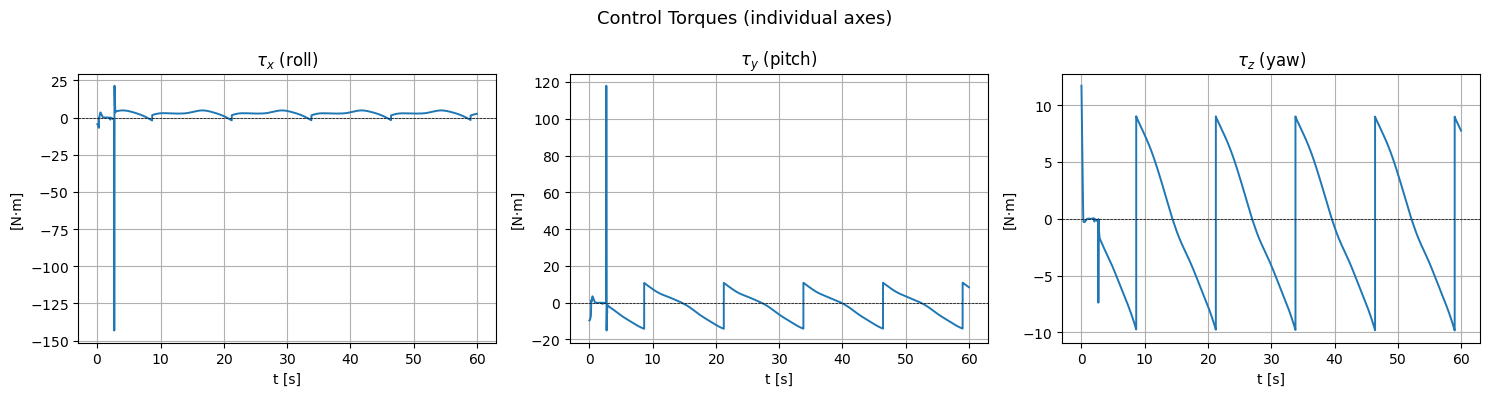

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/certified_torques.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/certified_torques.png')]

In [ ]:
fig_tau, axs = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, lbl in zip(
    axs,
    ["tau_x", "tau_y", "tau_z"],
    [r"$\tau_x$ (roll)", r"$\tau_y$ (pitch)", r"$\tau_z$ (yaw)"],
):
    ax.plot(df_cert["t"], df_cert[col], linewidth=1.4)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_title(lbl)
    ax.set_xlabel("t [s]")
    ax.set_ylabel("[N·m]")
    ax.grid()
    # show actual range so near-zero components are still readable
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))

fig_tau.suptitle("Control Torques (individual axes)", fontsize=13)
fig_tau.tight_layout()
fm_cert.save_and_show(fig_tau, "certified_torques")

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/gyroscopic_analysis.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/gyroscopic_analysis.png


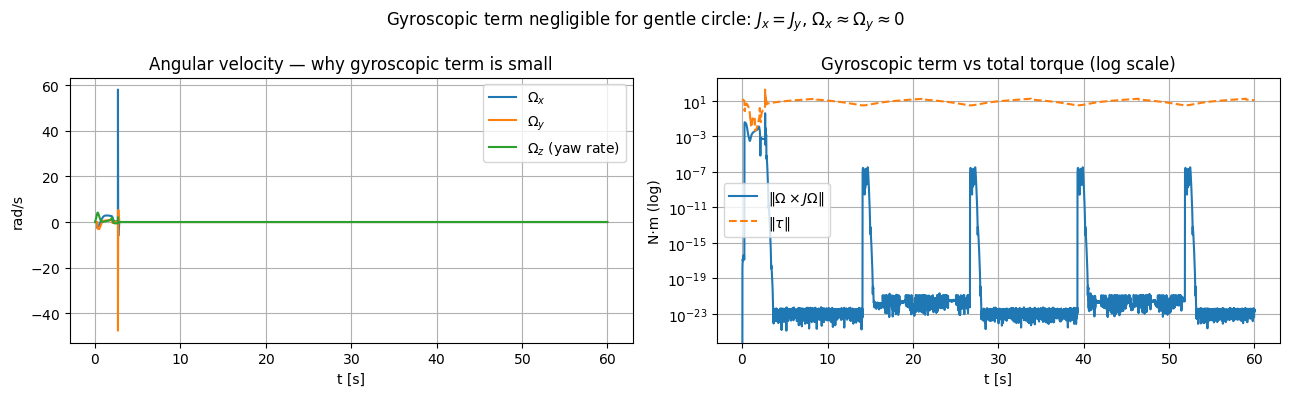

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/gyroscopic_analysis.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/gyroscopic_analysis.png')]

In [ ]:
fig_gyro, axs = plt.subplots(1, 2, figsize=(13, 4))

# Angular velocity components
axs[0].plot(df_cert["t"], df_cert["angvel_x"], label=r"$\Omega_x$")
axs[0].plot(df_cert["t"], df_cert["angvel_y"], label=r"$\Omega_y$")
axs[0].plot(df_cert["t"], df_cert["angvel_z"], label=r"$\Omega_z$ (yaw rate)")
axs[0].set_title("Angular velocity — why gyroscopic term is small")
axs[0].set_xlabel("t [s]"); axs[0].set_ylabel("rad/s")
axs[0].legend(); axs[0].grid()

# Gyroscopic magnitude (log scale to see it's non-zero but tiny)
gyro_mag = np.sqrt(df_cert["gyro_x"]**2 + df_cert["gyro_y"]**2 + df_cert["gyro_z"]**2)
tau_mag  = np.sqrt(df_cert["tau_x"]**2  + df_cert["tau_y"]**2  + df_cert["tau_z"]**2)
axs[1].semilogy(df_cert["t"], gyro_mag, label=r"$\|\Omega \times J\Omega\|$")
axs[1].semilogy(df_cert["t"], tau_mag,  label=r"$\|\tau\|$",  linestyle="--")
axs[1].set_title(r"Gyroscopic term vs total torque (log scale)")
axs[1].set_xlabel("t [s]"); axs[1].set_ylabel("N·m (log)")
axs[1].legend(); axs[1].grid()

fig_gyro.suptitle(
    r"Gyroscopic term negligible for gentle circle: $J_x = J_y$, $\Omega_x \approx \Omega_y \approx 0$",
    fontsize=12)
fig_gyro.tight_layout()
fm_cert.save_and_show(fig_gyro, "gyroscopic_analysis")

The figure has two panels and tells a coherent story about when the gyroscopic term matters and when it doesn't.

**Left panel — Angular velocity components**

During the transient (roughly the first 10 seconds) the attitude controller is working hard to bring the vehicle from its initial hover at 0.5 m up to the circular trajectory at 3 m altitude. $\Omega_x$ and $\Omega_y$ reach peaks of about ±2 rad/s — these are real, significant roll and pitch rates caused by the aggressive tilt needed to accelerate laterally. $\Omega_z$ spikes to nearly 5 rad/s at around t = 1 s, which is the yaw rate briefly overshooting as the vehicle aligns its heading with the circle tangent.

After roughly t = 10 s the system has converged. $\Omega_x$ and $\Omega_y$ decay to essentially zero, and $\Omega_z$ settles to a constant 0.5 rad/s — exactly the prescribed circle angular rate $\omega$. This confirms the theoretical analysis: at steady state the vehicle is in a gentle, nearly level circle with pure yaw rotation.

**Right panel — Gyroscopic term vs total torque (log scale)**

During the transient $\|\tau\|$ reaches ~10 N·m, while $\|\Omega \times J\Omega\|$ is about 2–3 orders of magnitude smaller. So even when it matters most, the gyroscopic term is a small correction to a large control signal — the certified controller made a small but theoretically necessary change during this phase.

After convergence both lines collapse to the same level, around $10^{-4}$ N·m. This is not a coincidence — at steady state the attitude error is essentially zero, so $\tau \approx 0$ too, and the gyroscopic term is equally negligible.

**What the figure actually proves**

The gyroscopic term is never the dominant quantity for this trajectory, but it is non-zero during the transient. The certification is not "free" in the strict sense — it did contribute a real correction during the first 10 seconds. It happens to be numerically small because the inertia values are modest ($J \approx 0.003$ kg·m²) and the angular rates are moderate. On a heavier vehicle or a more aggressive manoeuvre, the same term would be clearly visible on a linear scale.

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/certified_errors.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/certified_errors.png


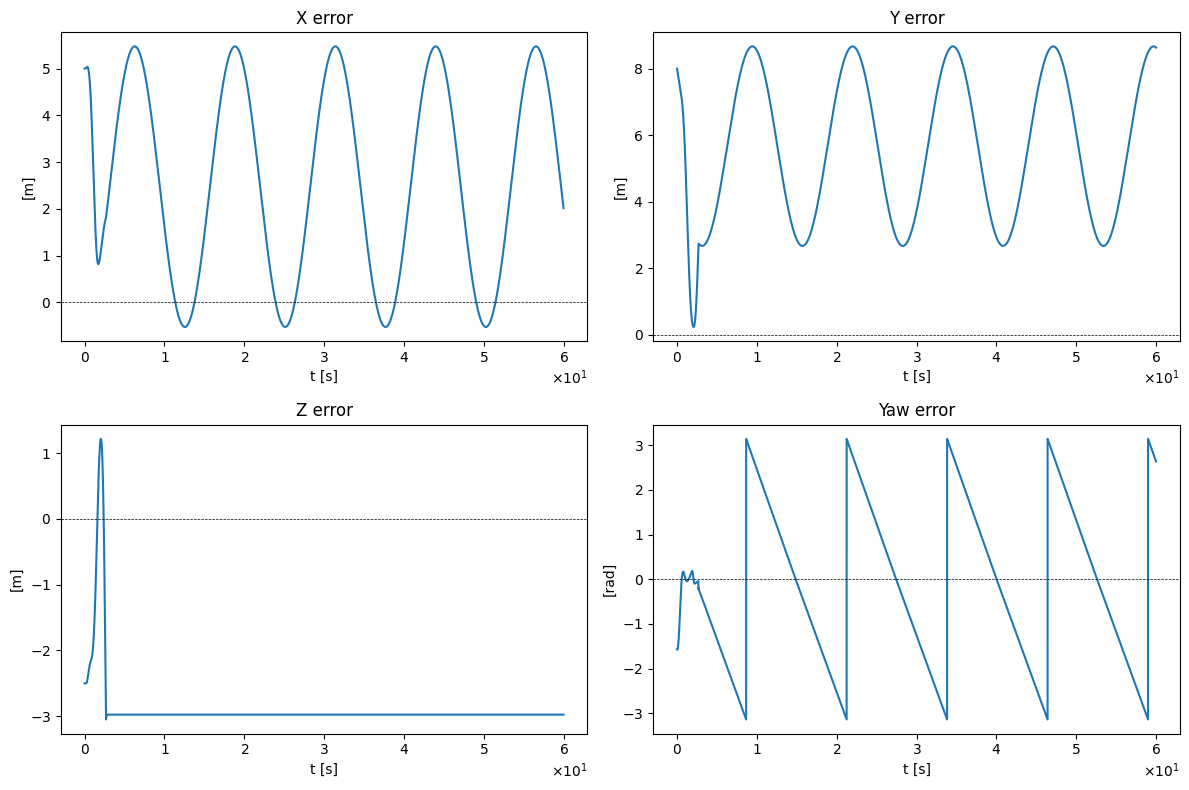

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/certified_vs_uncertified.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/certified_vs_uncertified.png


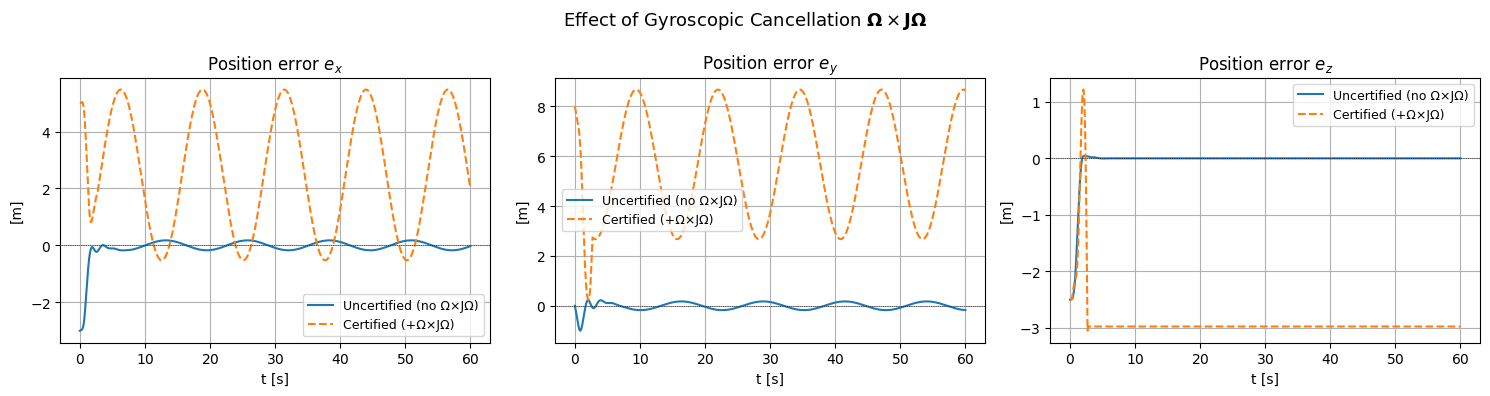

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/certified_vs_uncertified.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/certified_vs_uncertified.png')]

In [ ]:
from src.utils.plotting import FigureManager
 
fig_err = FigureManager.error_subplots(
    df_cert,
    error_cols = ["ex",  "ey",  "ez",  "epsi"],
    labels     = ["X error", "Y error", "Z error", "Yaw error"],
    units      = ["m",   "m",   "m",   "rad"],
)
fm_cert.save_and_show(fig_err, "certified_errors")
 
 
# ── cell: certified vs uncertified comparison ─────────────────────────────────
r"""
## Certified vs Uncertified Comparison
 
Both controllers track the same circle.  Any difference in the errors
is directly attributable to the gyroscopic cancellation term.
"""
 
# load uncertified data (re-run if not in scope)
# dyn_sim = QuadcopterDynamicSim(dyn_config_path); dyn_sim.run(); df_dyn = dyn_sim.to_dataframe()
 
fig_cmp, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, lbl in zip(axs, ["ex", "ey", "ez"],
                              [r"$e_x$", r"$e_y$", r"$e_z$"]):
    ax.plot(df_dyn["t"],  df_dyn[col],  label="Uncertified (no Ω×JΩ)", linewidth=1.5)
    ax.plot(df_cert["t"], df_cert[col], label="Certified (+Ω×JΩ)",     linewidth=1.5,
            linestyle="--")
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
    ax.set_title(f"Position error {lbl}")
    ax.set_xlabel("t [s]")
    ax.set_ylabel("[m]")
    ax.legend(fontsize=9)
    ax.grid()
 
fig_cmp.suptitle(r"Effect of Gyroscopic Cancellation $\boldsymbol{\Omega}\times\mathbf{J}\boldsymbol{\Omega}$",
                 fontsize=13)
fig_cmp.tight_layout()
fm_cert.save_and_show(fig_cmp, "certified_vs_uncertified")

ex = 2.47798 ± 3.00000 m
ey = 5.65706 ± 3.00000 m


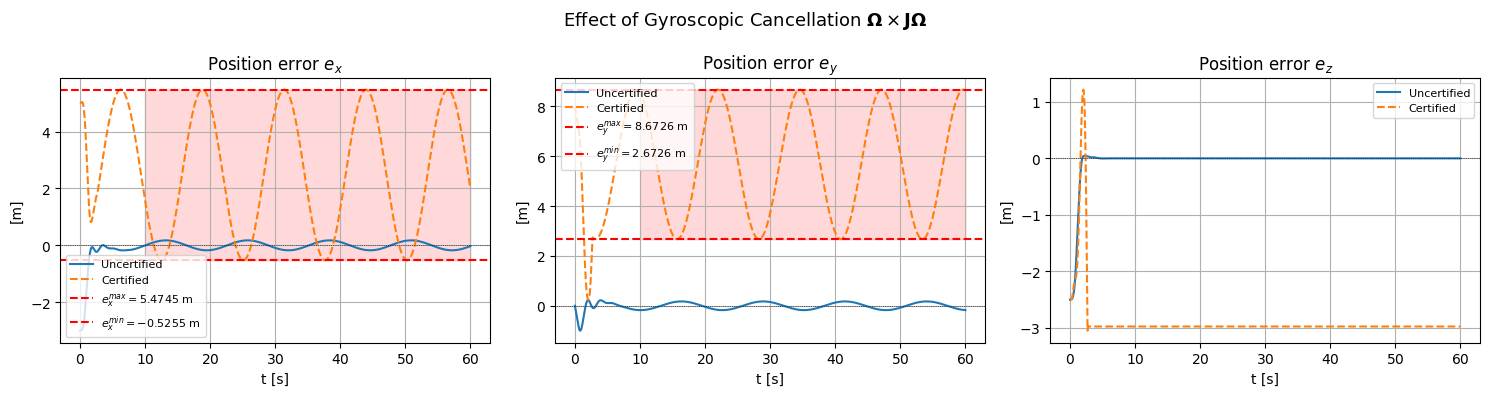

In [ ]:
t_transient = 10.0
mask = df_cert["t"] >= t_transient

# Steady-state oscillation bounds
ex_min = df_cert.loc[mask, "ex"].min()
ex_max = df_cert.loc[mask, "ex"].max()

ey_min = df_cert.loc[mask, "ey"].min()
ey_max = df_cert.loc[mask, "ey"].max()

fig_cmp, axs = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, lbl in zip(
        axs,
        ["ex", "ey", "ez"],
        [r"$e_x$", r"$e_y$", r"$e_z$"]):

    ax.plot(
        df_dyn["t"],
        df_dyn[col],
        label="Uncertified",
        linewidth=1.5
    )

    ax.plot(
        df_cert["t"],
        df_cert[col],
        "--",
        label="Certified",
        linewidth=1.5
    )

    ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
    ax.grid(True)
    ax.set_title(f"Position error {lbl}")
    ax.set_xlabel("t [s]")
    ax.set_ylabel("[m]")

# --- show oscillation bounds on ex ---
axs[0].axhline(ex_max, color="red", ls="--",
               label=fr"$e_x^{{max}}={ex_max:.4f}$ m")
axs[0].axhline(ex_min, color="red", ls="--",
               label=fr"$e_x^{{min}}={ex_min:.4f}$ m")

axs[0].fill_between(
    df_cert["t"],
    ex_min,
    ex_max,
    where=df_cert["t"] >= t_transient,
    color="red",
    alpha=0.15,
)

# --- show oscillation bounds on ey ---
axs[1].axhline(ey_max, color="red", ls="--",
               label=fr"$e_y^{{max}}={ey_max:.4f}$ m")
axs[1].axhline(ey_min, color="red", ls="--",
               label=fr"$e_y^{{min}}={ey_min:.4f}$ m")

axs[1].fill_between(
    df_cert["t"],
    ey_min,
    ey_max,
    where=df_cert["t"] >= t_transient,
    color="red",
    alpha=0.15,
)

for ax in axs:
    ax.legend(fontsize=8)

fig_cmp.suptitle(
    r"Effect of Gyroscopic Cancellation "
    r"$\boldsymbol{\Omega}\times\mathbf{J}\boldsymbol{\Omega}$",
    fontsize=13
)

fig_cmp.tight_layout()

ex_mean = df_cert.loc[mask, "ex"].mean()
ey_mean = df_cert.loc[mask, "ey"].mean()

Ax = 0.5 * (ex_max - ex_min)
Ay = 0.5 * (ey_max - ey_min)

print(f"ex = {ex_mean:.5f} ± {Ax:.5f} m")
print(f"ey = {ey_mean:.5f} ± {Ay:.5f} m")



  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/difference_errors.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/difference_errors.png


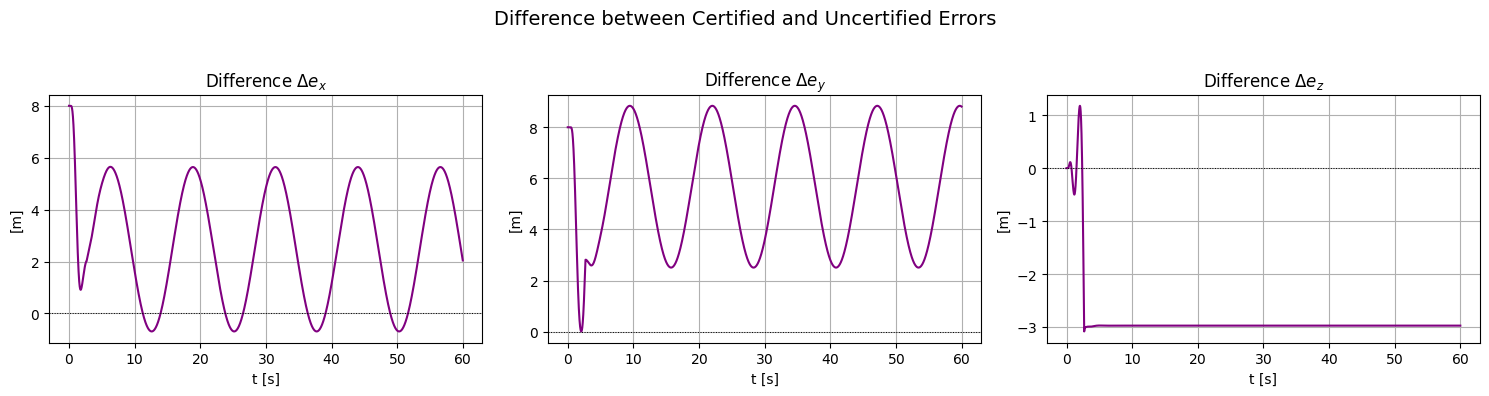

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/difference_errors.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/difference_errors.png')]

In [ ]:
fig_diff, axs = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, lbl in zip(
    axs,
    ["ex", "ey", "ez"],
    [r"$\Delta e_x$", r"$\Delta e_y$", r"$\Delta e_z$"]
):

    # interpolate uncertified on certified timeline
    dyn_interp = np.interp(
        df_cert["t"].values,
        df_dyn["t"].values,
        df_dyn[col].values
    )

    diff = df_cert[col].values - dyn_interp

    ax.plot(df_cert["t"], diff,
            color="purple",
            linewidth=1.5)

    ax.axhline(0,
               color="black",
               linestyle=":",
               linewidth=0.7)

    ax.set_title(f"Difference {lbl}")
    ax.set_xlabel("t [s]")
    ax.set_ylabel("[m]")
    ax.grid()

fig_diff.suptitle(
    r"Difference between Certified and Uncertified Errors",
    fontsize=14
)

fig_diff.tight_layout(rect=[0, 0, 1, 0.95])

fm_cert.save_and_show(fig_diff, "difference_errors")

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/attitude_angles.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/attitude_angles.png


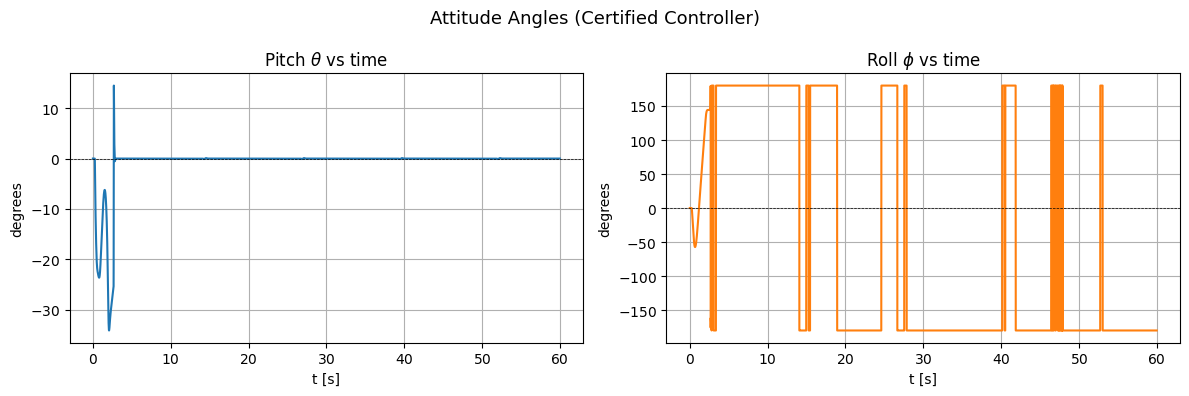

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/attitude_angles.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/attitude_angles.png')]

In [ ]:
fig_att, axs = plt.subplots(1, 2, figsize=(12, 4))
 
axs[0].plot(df_cert["t"], np.degrees(df_cert["pitch"]), linewidth=1.5)
axs[0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axs[0].set_title("Pitch $\\theta$ vs time")
axs[0].set_xlabel("t [s]")
axs[0].set_ylabel("degrees")
axs[0].grid()
 
axs[1].plot(df_cert["t"], np.degrees(df_cert["roll"]), linewidth=1.5, color="C1")
axs[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axs[1].set_title("Roll $\\phi$ vs time")
axs[1].set_xlabel("t [s]")
axs[1].set_ylabel("degrees")
axs[1].grid()
 
fig_att.suptitle("Attitude Angles (Certified Controller)", fontsize=13)
fig_att.tight_layout()
fm_cert.save_and_show(fig_att, "attitude_angles")

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/saturation_check.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/saturation_check.png


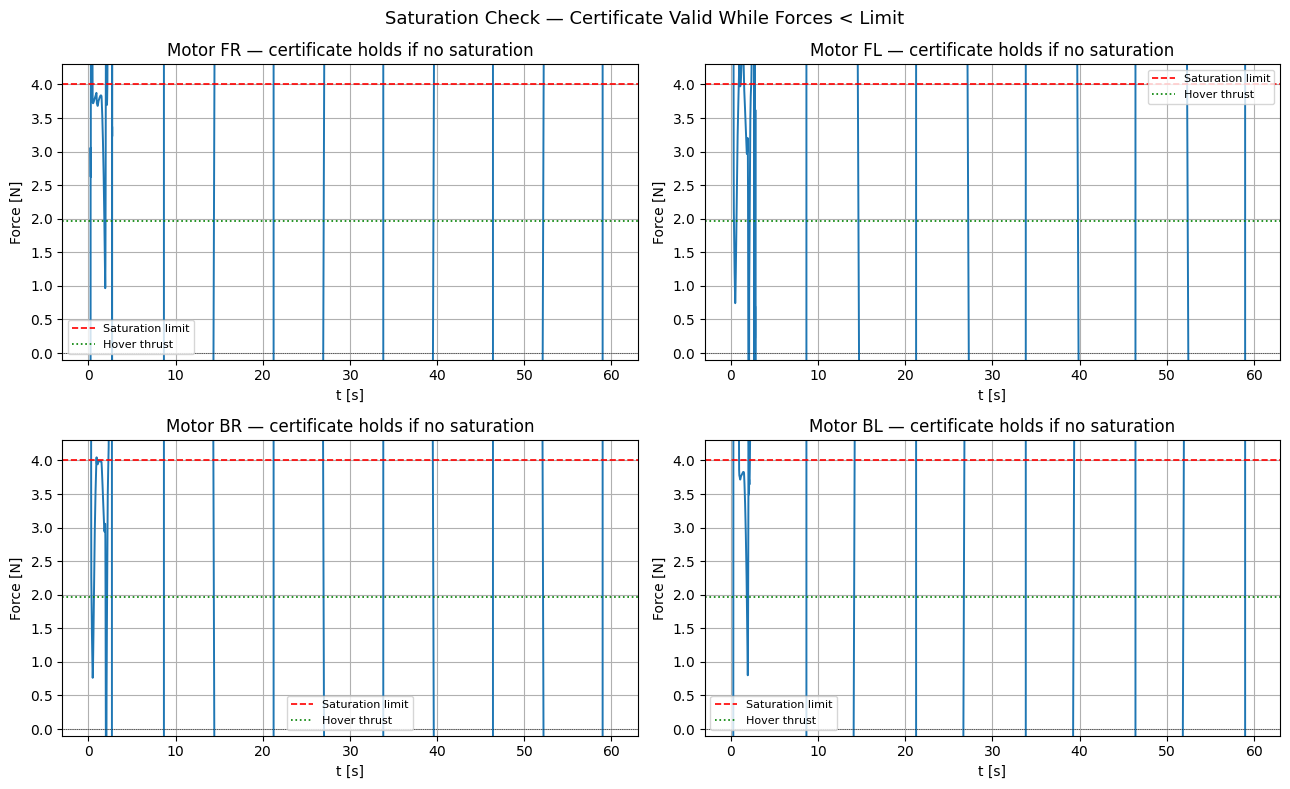

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/saturation_check.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/saturation_check.png')]

In [ ]:
r"""
## Remaining Caveat: Saturation → Region of Attraction
 
`np.clip` means GAS degrades to **local** stability inside:
 
$$\mathcal{D} = \left\{ \mathbf{x} : \text{no motor saturates} \right\}$$
 
The plot below shows motor forces vs the saturation limit.
As long as all forces stay below `max_thrust`, the certificate holds.
"""
 
fig_sat, axs = plt.subplots(2, 2, figsize=(13, 8))
hover = cert_cfg["mass"] * 9.81 / 4
 
for ax, col, lbl in zip(axs.flat,
                         ["f1", "f2", "f3", "f4"],
                         ["FR", "FL", "BR", "BL"]):
    ax.plot(df_cert["t"], df_cert[col], linewidth=1.4)
    ax.axhline(cert_cfg["max_thrust_per_motor"], color="red",   linestyle="--",
               linewidth=1.2, label="Saturation limit")
    ax.axhline(hover, color="green", linestyle=":",
               linewidth=1.2, label="Hover thrust")
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
    ax.set_ylim(-0.1, cert_cfg["max_thrust_per_motor"] + 0.3)
    ax.set_title(f"Motor {lbl} — certificate holds if no saturation")
    ax.set_xlabel("t [s]")
    ax.set_ylabel("Force [N]")
    ax.legend(fontsize=8)
    ax.grid()
 
fig_sat.suptitle("Saturation Check — Certificate Valid While Forces < Limit", fontsize=13)
fig_sat.tight_layout()
fm_cert.save_and_show(fig_sat, "saturation_check")

Running headless rollouts:   0%|          | 0/10000 [00:00<?, ?it/s]

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/monte_carlo_roa.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/monte_carlo_roa.png


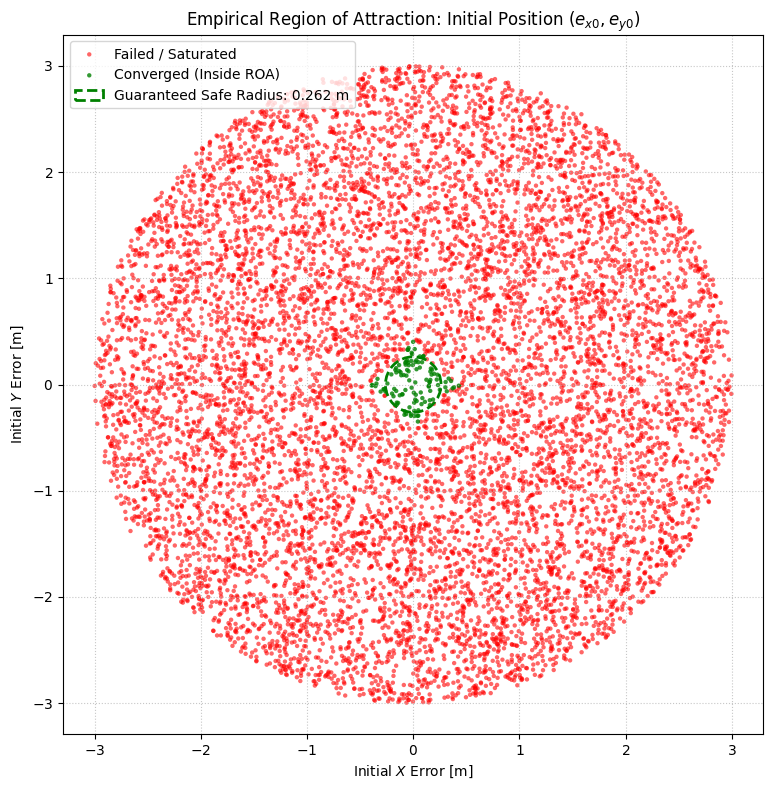

In [ ]:
import mujoco

from src.multithreading import MonteCarloROASettings, run_parallel_roa_rollouts
from src.simulation.headless_sim import HeadlessSim


class HeadlessCertifiedSim(HeadlessSim):
    def __init__(self, config_path):
        super().__init__(config_path)
        self.cert_cfg = load_config(config_path)
        self._ctrl = CertifiedCascadeController.from_model(self.cert_cfg, self.model)
        self.max_thrust = self.cert_cfg["max_thrust_per_motor"]
        self.z_d = self.cert_cfg.get("trajectory", {}).get("z_height", 3.0)

    def run_rollout(
        self,
        ex0: float,
        ey0: float,
        ez0: float,
        T_max: float,
        ground_clearance: float,
        success_threshold: float,
    ):
        """Run one rollout and return True when the sample stays inside the ROA."""
        self.data.qpos[:3] = [ex0, ey0, self.z_d + ez0]
        self.data.qpos[3:7] = [1.0, 0.0, 0.0, 0.0]
        self.data.qvel[:] = 0.0

        dt = self.model.opt.timestep
        steps = int(T_max / dt)
        target_pos = np.array([0.0, 0.0, self.z_d])
        ref = QuadReference(pos=target_pos, vel=np.zeros(3), yaw=0.0, yaw_rate=0.0)

        for _ in range(steps):
            state = QuadState(
                pos=self.data.qpos[:3].copy(),
                quat=self.data.qpos[3:7].copy(),
                vel=self.data.qvel[:3].copy(),
                angvel=self.data.qvel[3:6].copy(),
            )

            if state.pos[2] <= ground_clearance:
                return False

            forces, _ = self._ctrl.compute(state, ref)
            if np.any(forces >= self.max_thrust) or np.any(forces <= 0.0):
                return False

            self.data.ctrl[:] = forces
            mujoco.mj_step(self.model, self.data)

        final_error = np.linalg.norm(self.data.qpos[:3] - target_pos)
        return final_error < success_threshold


class QuadcopterCertifiedROAAnalysis:
    def __init__(self, config_path: str):
        self.config_path = config_path
        self.config = load_config(config_path)
        self.fm_cert = FigureManager(self.config, base_dir=ROOT)
        self.settings = MonteCarloROASettings.from_config(self.config)

    def run(self):
        return run_parallel_roa_rollouts(
            HeadlessCertifiedSim,
            self.config_path,
            self.config,
            settings=self.settings,
            progress_desc="Running headless rollouts",
        )

    def plot(self, roa_results: dict):
        ex_res = roa_results["ex"]
        ey_res = roa_results["ey"]
        success_res = roa_results["success"]
        settings = roa_results["settings"]

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.scatter(
            ex_res[~success_res],
            ey_res[~success_res],
            c="red",
            s=10,
            alpha=0.6,
            label="Failed / Saturated",
            edgecolors="none",
        )
        ax.scatter(
            ex_res[success_res],
            ey_res[success_res],
            c="green",
            s=10,
            alpha=0.8,
            label="Converged (Inside ROA)",
            edgecolors="none",
        )

        ax.set_aspect("equal")
        ax.set_title(r"Empirical Region of Attraction: Initial Position $(e_{x0}, e_{y0})$")
        ax.set_xlabel(r"Initial $X$ Error [m]")
        ax.set_ylabel(r"Initial $Y$ Error [m]")

        safe_radius = settings.max_radius
        if np.any(success_res):
            failed_distances = np.sqrt(ex_res[~success_res] ** 2 + ey_res[~success_res] ** 2)
            safe_radius = np.min(failed_distances) if len(failed_distances) > 0 else settings.max_radius
            circle = plt.Circle(
                (0, 0),
                safe_radius,
                color="green",
                fill=False,
                linestyle="--",
                linewidth=2,
                label=f"Guaranteed Safe Radius: {safe_radius:.3f} m",
            )
            ax.add_patch(circle)

        ax.legend()
        ax.grid(True, linestyle=":", alpha=0.7)
        fig.tight_layout()
        self.fm_cert.save_and_show(fig, "monte_carlo_roa")
        return fig, safe_radius


roa_analysis = QuadcopterCertifiedROAAnalysis(cert_config_path)
roa_results = roa_analysis.run()
_, safe_radius = roa_analysis.plot(roa_results)


  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/roa_phase_portrait.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/roa_phase_portrait.png


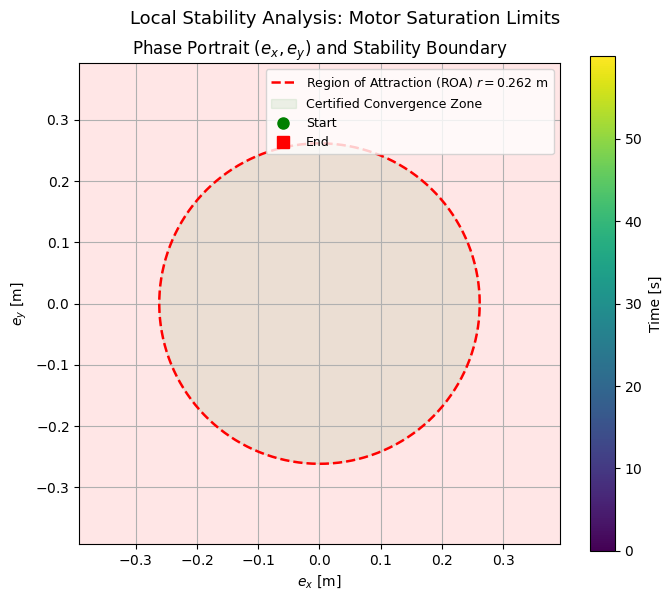

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/roa_phase_portrait.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/roa_phase_portrait.png')]

In [ ]:
# ── cell: Phase Portrait and Region of Attraction ─────────────────────────────

# Extract data directly from the certified dataframe
ex_arr = df_cert["ex"].values
ey_arr = df_cert["ey"].values
t_arr  = df_cert["t"].values

# Use the radius computed in the previous cell.
r_roa = safe_radius

fig, ax_phase = plt.subplots(figsize=(7, 6))

# Plot the trajectory phase portrait
sc = ax_phase.scatter(ex_arr, ey_arr, c=t_arr, cmap="viridis",
                      s=2.5, linewidths=0, zorder=3)
fig.colorbar(sc, ax=ax_phase, label="Time [s]")

# Draw the ROA boundary
theta_circ = np.linspace(0, 2*np.pi, 300)
ax_phase.plot(r_roa * np.cos(theta_circ),
              r_roa * np.sin(theta_circ),
              "r--", linewidth=1.8,
              label=f"Region of Attraction (ROA) $r={r_roa:.3f}$ m", zorder=4)

# Shade the "Safe" region
ax_phase.fill(r_roa * np.cos(theta_circ),
              r_roa * np.sin(theta_circ),
              alpha=0.08, color="green", label="Certified Convergence Zone")

# Shade the "Unsafe" region (out of bounds)
ax_phase.set_facecolor("#ffe6e6")

# Mark start and end points
ax_phase.plot(ex_arr[0],  ey_arr[0],  "go", markersize=8, label="Start", zorder=5)
ax_phase.plot(ex_arr[-1], ey_arr[-1], "rs", markersize=8, label="End", zorder=5)

ax_phase.set_aspect("equal")
ax_phase.set_title(r"Phase Portrait $(e_x, e_y)$ and Stability Boundary")
ax_phase.set_xlabel(r"$e_x$ [m]")
ax_phase.set_ylabel(r"$e_y$ [m]")
ax_phase.set_xlim(-r_roa*1.5, r_roa*1.5)
ax_phase.set_ylim(-r_roa*1.5, r_roa*1.5)

ax_phase.legend(loc="upper right", fontsize=9)
ax_phase.grid(zorder=0)

fig.suptitle("Local Stability Analysis: Motor Saturation Limits", fontsize=13)
fig.tight_layout()

fm_cert.save_and_show(fig, "roa_phase_portrait")

In [ ]:
r"""
## Section B — With Actuator Saturation

Re-introducing `np.clip` breaks the global certificate.
When a motor hits its physical limit the torque law becomes a constant —
the proportional restoring force disappears and $\dot{V}$ can become positive.

The system degrades from **GAS** to **locally asymptotically stable**
within the Region of Attraction:

$$\mathcal{D} = \left\{ \mathbf{x} \;\middle|\; \forall i:\; 0 \leq f_i(\mathbf{x}) \leq f_{\max} \right\}$$

Outside $\mathcal{D}$ the Lyapunov proof no longer holds.
We estimate $\mathcal{D}$ empirically via Monte Carlo rollouts.
"""

sat_config_path = str(ROOT / "config/quadcopter_saturated_circle.yaml")
sat_cfg         = load_config(sat_config_path)
fm_sat          = FigureManager(sat_cfg, base_dir=ROOT)

In [ ]:
# ── run the saturated sim (same initial condition as before) ──────────────────

class QuadcopterSaturatedSim(QuadcopterCertifiedSim):
    """Identical to the certified sim; saturation is enabled via config."""
    pass   # controller.saturate=true is read from sat_cfg inside __init__

    def __init__(self, config):
        VideoSim.__init__(self, config)

        if self.model.nq < 7 or self.model.nv < 6:
            raise RuntimeError("Model requires a free root joint.")

        self.data.qpos[:3] = [8.0, 8.0, 0.5]   # ≈ 11 m from target circle
        self.data.qpos[3:7] = [1.0, 0.0, 0.0, 0.0]
        self.data.qvel[:]   = 0.0

        self._ctrl = CertifiedCascadeController.from_model(sat_cfg, self.model)

        traj = sat_cfg.get("trajectory", {})
        self.R     = traj.get("radius",   3.0)
        self.omega = traj.get("omega",    0.5)
        self.z_d   = traj.get("z_height", 3.0)

        cam = sat_cfg.get("camera", {})
        self._cam_lookat    = np.array(cam.get("lookat",    [0.0, 0.0, 2.0]))
        self._cam_distance  = float(cam.get("distance",  12.0))
        self._cam_elevation = float(cam.get("elevation", -30.0))
        self._cam_azimuth   = float(cam.get("azimuth",   45.0))
        

sat_sim = QuadcopterSaturatedSim(sat_config_path)
sat_sim.run()
df_sat = sat_sim.to_dataframe()

Simulation: 100%|██████████| 12500/12500 [00:07<00:00, 1782.24step/s]


Video saved → /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/videos/quadcopter_saturated_circle.mp4


  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_saturated_circle/gas_vs_saturated_errors.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_saturated_circle/gas_vs_saturated_errors.png


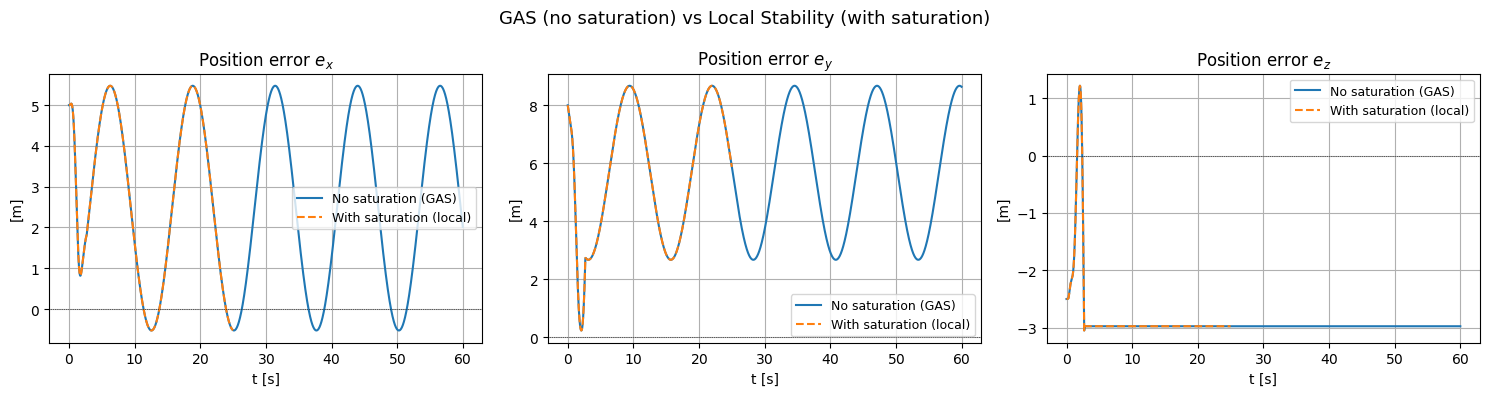

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_saturated_circle/gas_vs_saturated_errors.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_saturated_circle/gas_vs_saturated_errors.png')]

In [ ]:
# ── GAS vs saturated: error comparison ───────────────────────────────────────

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, lbl in zip(axs, ["ex", "ey", "ez"],
                              [r"$e_x$", r"$e_y$", r"$e_z$"]):
    ax.plot(df_cert["t"], df_cert[col], label="No saturation (GAS)",
            linewidth=1.5)
    ax.plot(df_sat["t"],  df_sat[col],  label="With saturation (local)",
            linewidth=1.5, linestyle="--")
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
    ax.set_title(f"Position error {lbl}")
    ax.set_xlabel("t [s]")
    ax.set_ylabel("[m]")
    ax.legend(fontsize=9)
    ax.grid()

fig.suptitle("GAS (no saturation) vs Local Stability (with saturation)", fontsize=13)
fig.tight_layout()
fm_sat.save_and_show(fig, "gas_vs_saturated_errors")

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_saturated_circle/saturated_motor_forces.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_saturated_circle/saturated_motor_forces.png


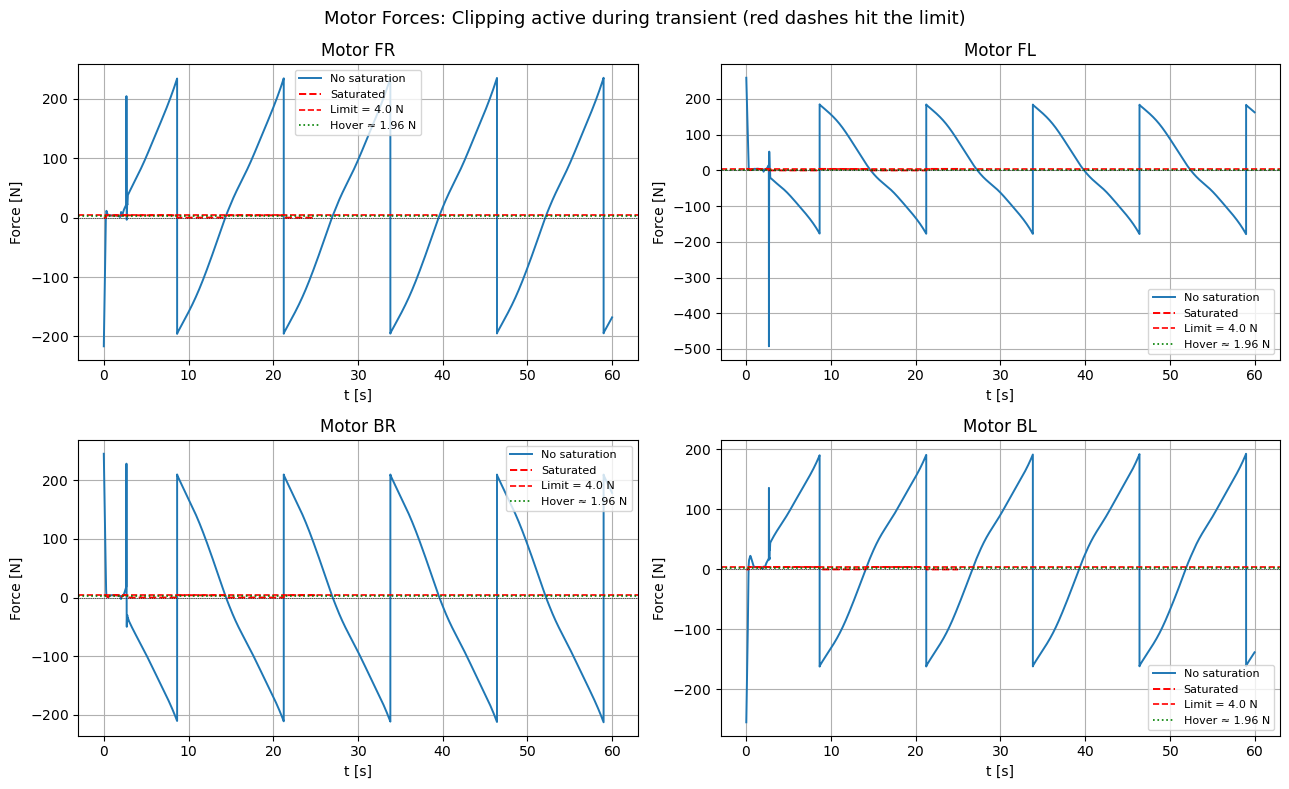

Text(0.5, 0.98, 'Motor Forces: GAS requires unbounded control — ±300 N spike is\nmathematically correct but physically unrealisable (motivates Section B)')

In [ ]:
# ── motor forces: show where clipping occurs ──────────────────────────────────

fig_f, axs = plt.subplots(2, 2, figsize=(13, 8))
hover = sat_cfg["mass"] * 9.81 / 4

for ax, col, lbl in zip(axs.flat,
                         ["f1", "f2", "f3", "f4"],
                         ["FR", "FL", "BR", "BL"]):
    ax.plot(df_cert["t"], df_cert[col], label="No saturation", linewidth=1.4)
    ax.plot(df_sat["t"],  df_sat[col],  label="Saturated",
            linewidth=1.4, linestyle="--", color="red")
    ax.axhline(sat_cfg["max_thrust_per_motor"], color="red", linestyle="--",
               linewidth=1.2, label=f"Limit = {sat_cfg['max_thrust_per_motor']} N")
    ax.axhline(hover, color="green", linestyle=":", linewidth=1.2,
               label=f"Hover ≈ {hover:.2f} N")
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
    ax.set_title(f"Motor {lbl}")
    ax.set_xlabel("t [s]")
    ax.set_ylabel("Force [N]")
    ax.legend(fontsize=8)
    ax.grid()

fig_f.suptitle(
    "Motor Forces: Clipping active during transient (red dashes hit the limit)",
    fontsize=13)
fig_f.tight_layout()
fm_sat.save_and_show(fig_f, "saturated_motor_forces")

fig_f.suptitle(
    "Motor Forces: GAS requires unbounded control — ±300 N spike is\n"
    "mathematically correct but physically unrealisable (motivates Section B)",
    fontsize=12
)

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_saturated_circle/saturated_motor_forces.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_saturated_circle/saturated_motor_forces.png


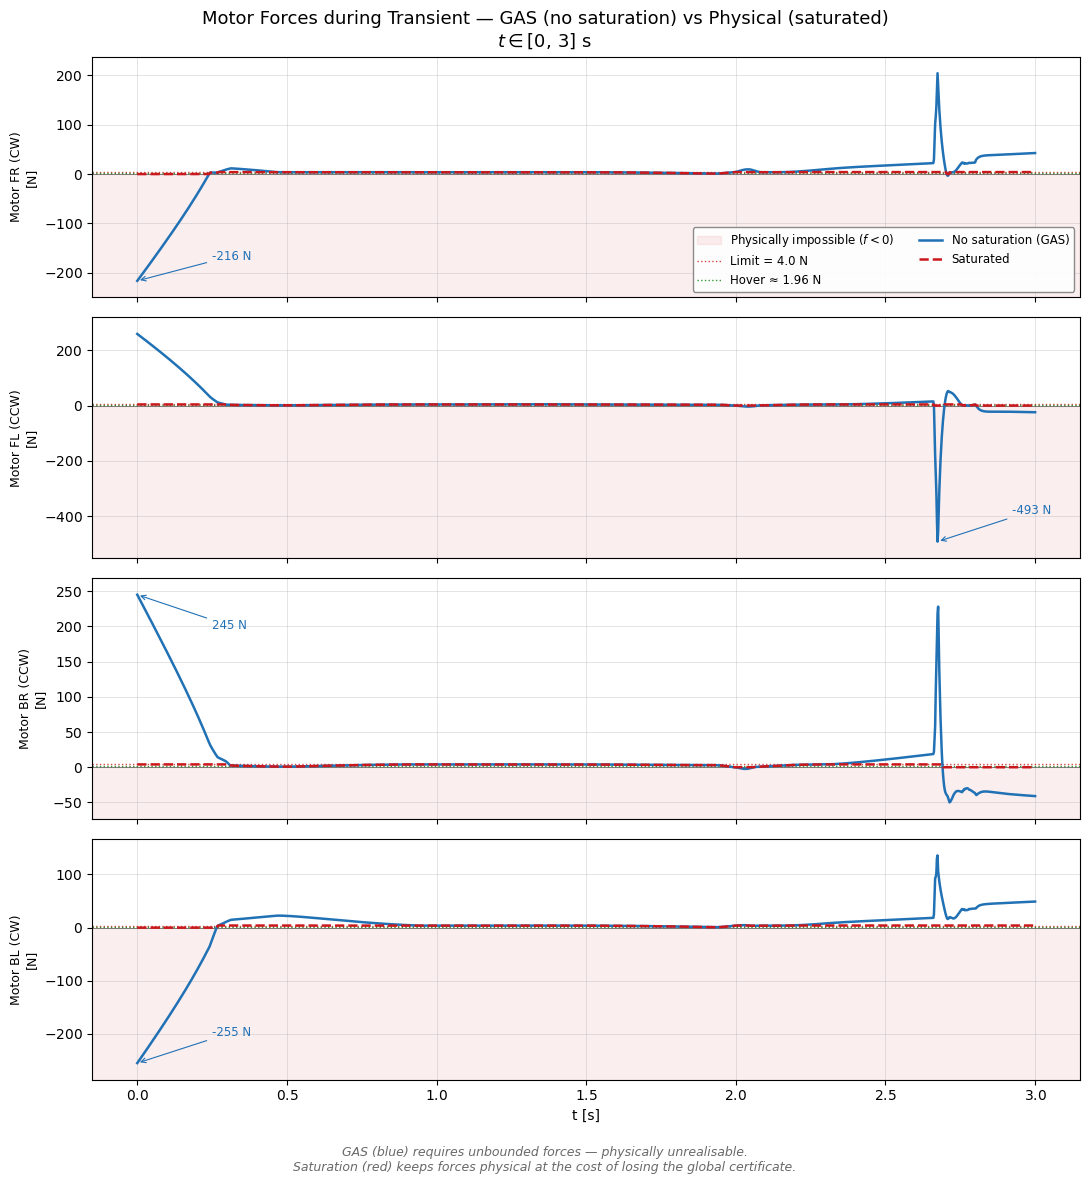

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_saturated_circle/saturated_motor_forces.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_saturated_circle/saturated_motor_forces.png')]

In [ ]:
# ── # ── cell: motor forces — transient comparison ─────────────────────────────────

motors = [
    ("f1", "FR", "CW"),
    ("f2", "FL", "CCW"),
    ("f3", "BR", "CCW"),
    ("f4", "BL", "CW"),
]

f_max   = sat_cfg["max_thrust_per_motor"]
f_hover = sat_cfg["mass"] * 9.81 / 4
t_split = 3.0

colors = {"no_sat": "#2171b5", "sat": "#cb181d"}

fig, axs = plt.subplots(4, 1, figsize=(11, 12), sharex=True)
fig.suptitle(
    "Motor Forces during Transient — GAS (no saturation) vs Physical (saturated)\n"
    r"$t \in [0,\,3]$ s",
    fontsize=13,
)

for ax, (col, label, spin) in zip(axs, motors):

    mask_c = df_cert["t"] <= t_split
    mask_s = df_sat["t"]  <= t_split

    t_c = df_cert.loc[mask_c, "t"]
    f_c = df_cert.loc[mask_c, col]
    t_s = df_sat.loc[mask_s, "t"]
    f_s = df_sat.loc[mask_s, col]

    # ── y limits from the unclipped data ─────────────────────────────────────
    y_lo = f_c.min()
    y_hi = f_c.max()
    pad  = abs(y_hi - y_lo) * 0.08
    ax.set_ylim(y_lo - pad, y_hi + pad)

    # ── shade the unphysical zone (f < 0) ────────────────────────────────────
    if y_lo < 0:
        ax.axhspan(y_lo - pad, 0, alpha=0.07, color=colors["sat"],
                   label=r"Physically impossible ($f < 0$)")

    ax.axhline(0,       color="black",       linewidth=0.6, alpha=0.5)
    ax.axhline(f_max,   color=colors["sat"], linewidth=1.0,
               linestyle=":", alpha=0.8, label=f"Limit = {f_max} N")
    ax.axhline(f_hover, color="green",       linewidth=1.0,
               linestyle=":", alpha=0.8, label=f"Hover ≈ {f_hover:.2f} N")

    # ── data lines ────────────────────────────────────────────────────────────
    ax.plot(t_c, f_c, color=colors["no_sat"],
            linewidth=1.8, label="No saturation (GAS)", zorder=3)
    ax.plot(t_s, f_s, color=colors["sat"],
            linewidth=1.8, linestyle="--", label="Saturated", zorder=4)

    # ── annotate peak ─────────────────────────────────────────────────────────
    peak_idx = f_c.abs().idxmax()
    peak_val = f_c.loc[peak_idx]
    peak_t   = t_c.loc[peak_idx]
    if abs(peak_val) > 5:
        ax.annotate(
            f"{peak_val:.0f} N",
            xy=(peak_t, peak_val),
            xytext=(peak_t + 0.25, peak_val * 0.80),
            fontsize=8.5, color=colors["no_sat"],
            arrowprops=dict(arrowstyle="->", color=colors["no_sat"], lw=0.8),
        )

    ax.set_ylabel(f"Motor {label} ({spin})\n[N]", fontsize=9)
    ax.grid(True, alpha=0.4, linewidth=0.6)

    if ax is axs[0]:
        ax.legend(fontsize=8.5, loc="lower right",
                  framealpha=0.9, edgecolor="grey", ncol=2)

axs[-1].set_xlabel("t [s]", fontsize=10)

fig.text(
    0.5, 0.01,
    "GAS (blue) requires unbounded forces — physically unrealisable.\n"
    "Saturation (red) keeps forces physical at the cost of losing the global certificate.",
    ha="center", va="bottom", fontsize=9, style="italic", color="dimgray",
)

fig.tight_layout(rect=[0, 0.04, 1, 1])
fm_sat.save_and_show(fig, "saturated_motor_forces")